# Dataset Comparison: Synthetic Educational Dataset vs. Real UCI Benchmark Dataset
## Architectural Comparison, Feature Differences & Modeling Utility
### Credit Risk & Loan Decision Intelligence Platform

---

## SECTION 1 — Purpose of Dual-Dataset Architecture

The platform deliberately maintains two independent raw datasets to serve distinct architectural and analytical roles:

1. **Synthetic Educational Dataset (`data/raw/credit_risk_50.csv`)**:
   - 50 synthetic applicant records modeled on the Indian digital lending ecosystem (INR currency ₹, CIBIL credit scores 300–900).
   - Designed for rapid end-to-end prototyping of the entire platform architecture: Flow A (identity verification / PAN / KYC / bank statements) and Flow B (credit ML pipeline).
   
2. **Real-World Historical Credit-Risk Benchmark Dataset (`data/raw/german_credit_1000.csv`)**:
   - 1,000 historical bank loan records from the UCI Machine Learning Repository (Statlog German Credit Data, 1994).
   - Designed for empirical machine learning benchmarking, cross-validation, feature importance exploration, and decision policy stress-testing.

> **CRITICAL GOVERNANCE RULE**: The two datasets represent different currencies, economic systems, and feature sets. They are **NEVER combined or merged into a single training dataset**.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

print("Comparison notebook initialized.")

Comparison notebook initialized.


---
## SECTION 2 — Load Both Datasets Programmatically

We dynamically load both raw datasets from `data/raw/`.

In [2]:
synth_path = '../data/raw/credit_risk_50.csv' if os.path.exists('../data/raw/credit_risk_50.csv') else 'data/raw/credit_risk_50.csv'
real_path = '../data/raw/german_credit_1000.csv' if os.path.exists('../data/raw/german_credit_1000.csv') else 'data/raw/german_credit_1000.csv'

df_synthetic = pd.read_csv(synth_path)
df_real = pd.read_csv(real_path)

print(f"Datasets Loaded:")
print(f"  • Synthetic Dataset Shape : {df_synthetic.shape}")
print(f"  • Real UCI Dataset Shape  : {df_real.shape}")

Datasets Loaded:
  • Synthetic Dataset Shape : (50, 16)
  • Real UCI Dataset Shape  : (1000, 21)


---
## SECTION 3 — Dynamic Structural & Dimension Comparison

We dynamically compare key structural properties between the two datasets.

In [3]:
synth_num = df_synthetic.select_dtypes(include=[np.number]).columns.drop('default', errors='ignore').drop('applicant_id', errors='ignore').tolist()
synth_cat = df_synthetic.select_dtypes(include=['object', 'category']).columns.tolist()

real_num = df_real.select_dtypes(include=[np.number]).columns.drop('default', errors='ignore').tolist()
real_cat = df_real.select_dtypes(include=['object', 'category']).columns.tolist()

comp_metrics = {
    'Property': [
        'Total Record Count',
        'Total Columns',
        'Predictive Features',
        'Numerical Features',
        'Categorical Features',
        'Target Default Rate (%)',
        'Target Non-Default Count',
        'Target Default Count',
        'Missing Values',
        'Duplicate Rows'
    ],
    'Synthetic Dataset (50 rows)': [
        len(df_synthetic),
        df_synthetic.shape[1],
        len(synth_num) + len(synth_cat),
        len(synth_num),
        len(synth_cat),
        f"{df_synthetic['default'].mean()*100:.1f}%",
        int((df_synthetic['default'] == 0).sum()),
        int((df_synthetic['default'] == 1).sum()),
        int(df_synthetic.isnull().sum().sum()),
        int(df_synthetic.duplicated().sum())
    ],
    'Real UCI Benchmark Dataset (1,000 rows)': [
        len(df_real),
        df_real.shape[1],
        len(real_num) + len(real_cat),
        len(real_num),
        len(real_cat),
        f"{df_real['default'].mean()*100:.1f}%",
        int((df_real['default'] == 0).sum()),
        int((df_real['default'] == 1).sum()),
        int(df_real.isnull().sum().sum()),
        int(df_real.duplicated().sum())
    ]
}

comp_df = pd.DataFrame(comp_metrics)
print("Structural Comparison Table:")
display(comp_df)

Structural Comparison Table:


,Property,Synthetic Dataset (50 rows),"Real UCI Benchmark Dataset (1,000 rows)"
0,Total Record Count,50,1000
1,Total Columns,16,21
2,Predictive Features,14,20
3,Numerical Features,13,7
4,Categorical Features,1,13
5,Target Default Rate (%),38.0%,30.0%
6,Target Non-Default Count,31,700
7,Target Default Count,19,300
8,Missing Values,0,0
9,Duplicate Rows,0,0


---
## SECTION 4 — Domain Context & Schema Differences

| Dimension | Synthetic Development Dataset (`credit_risk_50.csv`) | Real UCI Benchmark Dataset (`german_credit_1000.csv`) |
|---|---|---|
| **Origin & Provenance** | Custom synthetic generation | UCI Machine Learning Repository (Prof. Dr. Hans Hofmann, 1994) |
| **Geographic Context** | India (Domestic retail lending) | Germany (European retail banking) |
| **Currency** | Indian Rupee (INR ₹) | Deutsche Mark (DM) |
| **Credit Bureau Metric** | Three-digit credit score (CIBIL 605–800) | Categorical credit history codes (`A30`–`A34`) |
| **Employment Taxonomy** | Nominal categories (`Salaried`, `Self-employed`, `Business`) | Duration categories (`A71`–`A75`) + Job type (`A171`–`A174`) |
| **Integration with Flow A** | Directly integrated with PAN / KYC / mobile verification mock modules | Decoupled; strictly evaluated in credit ML pipeline |
| **Primary Utility** | Architecture validation & product simulation testing | Statistical machine learning benchmark & cross-validation |

---
## SECTION 5 — Visualizing Sample Size & Target Comparison

We compare the sample sizes and target distributions graphically.

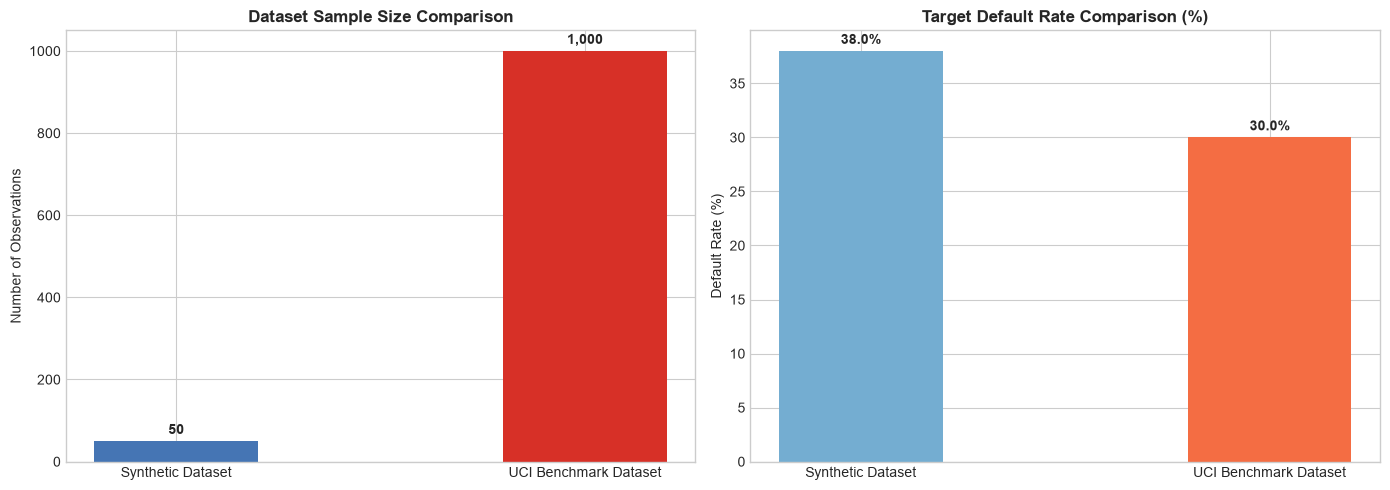

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample size comparison
axes[0].bar(['Synthetic Dataset', 'UCI Benchmark Dataset'], [len(df_synthetic), len(df_real)], color=['#4575b4', '#d73027'], width=0.4)
axes[0].set_title('Dataset Sample Size Comparison', fontweight='bold')
axes[0].set_ylabel('Number of Observations')
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height()):,}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')

# Target distribution comparison
rates = [df_synthetic['default'].mean() * 100, df_real['default'].mean() * 100]
axes[1].bar(['Synthetic Dataset', 'UCI Benchmark Dataset'], rates, color=['#74add1', '#f46d43'], width=0.4)
axes[1].set_title('Target Default Rate Comparison (%)', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

---
## SECTION 6 — Statistical Power & Modeling Utility

### Why Both Datasets Are Valuable:
1. **50-Row Synthetic Dataset (40 Train / 10 Test)**:
   - Fast to inspect manually.
   - Ideal for debugging unit tests, mocking edge cases, and testing UI dashboards.
   - Small sample limits statistical generalization.
2. **1,000-Row UCI Dataset (800 Train / 200 Test)**:
   - Sufficient observations to support 5-Fold Stratified Cross-Validation without severe fold variance.
   - Provides meaningful discrimination metric comparisons (ROC-AUC, Precision-Recall curves).
   - Real-world benchmark standard for algorithm comparison.

---
## SECTION 7 — Automated Validation Gates

We execute 10 programmatic validation checks.

In [5]:
print("Running Dataset Comparison Automated Validation Gates...")

# Gate 1: Synthetic record count
assert len(df_synthetic) == 50, f"Expected 50 synthetic records, found {len(df_synthetic)}"
print("  ✓ Gate 1: Synthetic record count == 50 confirmed.")

# Gate 2: Real record count
assert len(df_real) == 1000, f"Expected 1000 real records, found {len(df_real)}"
print("  ✓ Gate 2: Real benchmark record count == 1,000 confirmed.")

# Gate 3: Datasets are independent dataframes
assert df_synthetic is not df_real, "Dataframe identity collision!"
print("  ✓ Gate 3: Independent dataset instances verified.")

# Gate 4: Zero missing values across both datasets
assert df_synthetic.isnull().sum().sum() == 0 and df_real.isnull().sum().sum() == 0, "Missing values detected!"
print("  ✓ Gate 4: Zero missing values in both datasets confirmed.")

# Gate 5: Both datasets have binary target 'default'
assert set(df_synthetic['default'].unique()) == {0, 1} and set(df_real['default'].unique()) == {0, 1}, "Target value mismatch!"
print("  ✓ Gate 5: Binary target 'default' {0, 1} confirmed in both datasets.")

# Gate 6: Different feature column sets (authentic schemas preserved)
assert set(df_synthetic.columns) != set(df_real.columns), "Schemas should not be identical!"
print("  ✓ Gate 6: Schema authenticity preserved (different column sets).")

# Gate 7: Synthetic dataset has applicant_id identifier
assert 'applicant_id' in df_synthetic.columns, "applicant_id missing from synthetic dataset!"
print("  ✓ Gate 7: applicant_id identifier present in synthetic dataset.")

# Gate 8: Real dataset does NOT contain synthetic Indian KYC fields
for kyc_col in ['pan_verified', 'kyc_verified', 'mobile_verified', 'aadhaar_kyc']:
    assert kyc_col not in df_real.columns, f"Unexpected synthetic KYC column '{kyc_col}' found in real dataset!"
print("  ✓ Gate 8: Real dataset contains zero synthetic Indian KYC fields.")

# Gate 9: Comparison dataframe populated
assert comp_df.shape[0] == 10 and comp_df.shape[1] == 3, "Comparison table shape mismatch!"
print("  ✓ Gate 9: Comparison table dynamically populated (10 metrics).")

# Gate 10: Both datasets remain intact
assert len(df_synthetic) == 50 and len(df_real) == 1000, "Dataset corruption detected!"
print("  ✓ Gate 10: Both datasets intact and isolated.")

print("\n" + "="*60)
print("ALL 10 DATASET COMPARISON VALIDATION GATES PASSED!")
print("="*60)

Running Dataset Comparison Automated Validation Gates...
  ✓ Gate 1: Synthetic record count == 50 confirmed.
  ✓ Gate 2: Real benchmark record count == 1,000 confirmed.
  ✓ Gate 3: Independent dataset instances verified.
  ✓ Gate 4: Zero missing values in both datasets confirmed.
  ✓ Gate 5: Binary target 'default' {0, 1} confirmed in both datasets.
  ✓ Gate 6: Schema authenticity preserved (different column sets).
  ✓ Gate 7: applicant_id identifier present in synthetic dataset.
  ✓ Gate 8: Real dataset contains zero synthetic Indian KYC fields.
  ✓ Gate 9: Comparison table dynamically populated (10 metrics).
  ✓ Gate 10: Both datasets intact and isolated.

ALL 10 DATASET COMPARISON VALIDATION GATES PASSED!
